In [16]:
%pip install scikit-image
import numpy as np
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import ndimage
import skimage.segmentation as seg
from skimage.feature import peak_local_max
from skimage.segmentation import watershed


Note: you may need to restart the kernel to use updated packages.


In [17]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
torch.manual_seed(3)
  train_dir = Path('../train')

#extracts all the images and masks

def load_image_and_mask(train_dir, imageid, target_size=256):
  #we define all the right paths
  folder_path= train_dir/imageid
  image_path = folder_path/'images'/ f'{imageid}.png'
  mask_path= folder_path/'masks'

  #make all the images the same size, annd format, cause there are grayscale, and rgb
  image = Image.open(image_path).convert('RGB')
  image = image.resize((target_size, target_size), Image.BILINEAR)
  image_array= np.array(image)

  #combine the masks
  mask_files= os.listdir(mask_path)
  all_masks= np.zeros((target_size, target_size), dtype=np.uint8) # unit8 is specified for storage reasons, cause a mask is a positive int from 0-255
  for maskname in mask_files:
    imask_path= mask_path/maskname
    mask= Image.open(imask_path).convert('L')#L stands for grayscale
    mask= mask.resize((target_size, target_size), Image.NEAREST)
    mask_array= np.array(mask)

    all_masks= np.maximum(all_masks, mask_array)

  binary_mask = (all_masks > 128).astype(np.uint8)

  return image_array, binary_mask


In [19]:
def binary_mask_to_instances_watershed(binary_mask):
    #that one can handles overlapping, sets the distance to the nearest background
    
    distance = ndimage.distance_transform_edt(binary_mask)
    
    # Find nucleus centers (local maxima of the distance map)
    coords   = peak_local_max(distance, min_distance=5, labels=binary_mask)
    markers  = np.zeros_like(distance, dtype=int)
    markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    
    # Watershed "floods" from each center outward, stopping at boundaries
    labeled_mask = watershed(-distance, markers, mask=binary_mask)
    
    return labeled_mask, labeled_mask.max()

In [20]:
#now we will convert all the arrays in tensor so as to be able to work later with the transformers
class MyDataset (Dataset):
  def __init__(self, train_dir, target_size):
    self.train_dir= train_dir
    self.target_size= target_size
    self.image_name= []

    all_data= os.listdir(train_dir)

    for files in all_data:

      fullpath= train_dir/files

      if os.path.isdir(fullpath):
        self.image_name.append(files)

    self.image_name.sort()


  def __len__(self):
    return len(self.image_name)

  def __getitem__(self, idx):
    image_id= self.image_name[idx]
    image, mask= load_image_and_mask(self.train_dir, image_id, self.target_size)

    #we change the order cause a tensor has first the channel,height, width, while numpy has height, width, channels
    image_tensor= torch.tensor(image, dtype=torch.float32).permute(2,0,1)/ 255.0
    mask_tensor= torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

    return image_tensor, mask_tensor


In [21]:
batch_size=8
target_size=256
full_dataset= MyDataset(train_dir, target_size=target_size)
#out of the training set we are getting some to form a validation group, to check overfitting and manage hyperparameters
train_size=int(0.85* len(full_dataset)) 
valid_size= len(full_dataset) - train_size

train_dataset, valid_dataset = random_split(full_dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader  = DataLoader(valid_dataset, batch_size=batch_size)
# checking thefirst batch of data
# images_batch, masks_batch = next(iter(train_loader))

# print("=== ΕΛΕΓΧΟΣ ΔΙΑΣΤΑΣΕΩΝ ===")
# print("Images Batch Shape:", images_batch.shape)
# print("Masks Batch Shape:", masks_batch.shape)
# print("Τύπος Δεδομένων Εικόνας:", images_batch.dtype)
# print("Μέγιστη τιμή pixel εικόνας:", images_batch.max().item())
# print(f"Train: {train_size}  |  Val: {valid_size}")

In [22]:
#now we have 2d images , but the input of a transformer can only be an 1d sequence, so we will break it down to 1dbatches
class PatchEmbedding(nn.Module):
    def __init__(self, input_dim=3, embed_dim=256, patch_size=16):
        super().__init__()
        self.patch_size=patch_size
        self.input_proj= nn.Conv2d(input_dim,embed_dim,kernel_size=patch_size, stride=patch_size) #we create squares of patch_size that are not overlapped

    def forward(self, x):
        x=self.input_proj(x) # x [Batch_Size, Channels= embed_dim, patch height,patch Width]
        x= x.flatten(2) #cause we want it a row vector so batch, embedd, total patches 
        x=x.transpose(2,1) # for the tranformer we want the order to be batch, total patches, embedded
        return x


In [23]:
class PositionalEncoding(nn.Module):
    #we localize every patch in the sequence
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [24]:
def scaled_self_attention(q, k, v):
    #we are forming the dot product attention Q*K/sqrt(dk), then softmax
    d_k = q.shape[-1]
    logits = torch.matmul(q, k.transpose(-2, -1))
    logits = logits / math.sqrt(d_k)
    attention = F.softmax(logits, dim=-1)
    output = torch.matmul(attention, v)
    return output, attention

In [25]:
class MHA(nn.Module):
    #we are setting how much attention will pay every patch to the other, and they are forming the correlations between them
    def __init__(self, embed_dim=256, num_heads=8):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv_proj = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        def split_heads(t):
            return t.view(B, N, self.num_heads, self.head_dim).transpose(1, 2).reshape(B * self.num_heads, N, self.head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)
        out, attention_weights = scaled_self_attention(q, k, v)
        
        out = out.reshape(B, self.num_heads, N, self.head_dim).transpose(1, 2).reshape(B, N, D)
        attention_weights = attention_weights.reshape(B, self.num_heads, N, N).mean(dim=1)
        
        return self.out_proj(out), attention_weights

In [26]:
class Transformer(nn.Module):
    #main structure of the transformer, we use GELU for the non linearity, and we add the input back to the output to learn better
    def __init__(self, embed_dim=256, ff_dim=1024):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MHA(embed_dim=embed_dim, num_heads=8)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
        )
        
    def forward(self, x):
        res1 = x
        norm=self.norm1(x)
        attn_out, attn_weights = self.attn(norm)
        x = res1 + attn_out
        
        res2 = x
        x = res2 + self.ff(self.norm2(x))
        return x, attn_weights

In [27]:
class ViT(nn.Module):
    #we are forming everything together to create the Vision Transformer
    def __init__(self, input_dim=3, image_size=256, patch_size=16, embed_dim=256, num_classes=1, layers=4):
        super().__init__()
        self.patch_size=patch_size
        self.image_size=image_size
        self.patch_embed = PatchEmbedding(input_dim, embed_dim, patch_size)
        self.pos_encod= PositionalEncoding(embed_dim)

        #we are stting it in a block so as to form more complex correlations
        self.transformer_blocks=nn.ModuleList()
        for _ in range(layers):
            block=Transformer(embed_dim=embed_dim, ff_dim=1024)
            self.transformer_blocks.append(block)
        

        self.segmentation_head = nn.ConvTranspose2d(
            in_channels=embed_dim, 
            out_channels=num_classes,
            kernel_size=patch_size, 
            stride=patch_size)

    def forward(self, x):
        x = self.patch_embed(x) #x=[Batch, 256 Patches, 256 Embed]
        x=self.pos_encod(x)
        
        
        attn_weights = None
        for block in self.transformer_blocks:
            x, attn_weights = block(x)

        x = x.transpose(1, 2) #x=[Batch, Embed, Patches]
        
        batch_size = x.shape[0]
        embed_dim = x.shape[1]
        patches= self.image_size// self.patch_size
        x = x.view(batch_size, embed_dim, patches, patches) 
        

        masks = self.segmentation_head(x) # mask=[Batch, 1, 256, 256]
        
        return masks, attn_weights


In [28]:
model = ViT(input_dim=3, patch_size=16, embed_dim=256, num_classes=1)
#checking
# predicted_masks, attention_weights = model(images_batch)

# print("=== ΤΕΛΙΚΟΣ ΕΛΕΓΧΟΣ ΜΟΝΤΕΛΟΥ ===")
# print("Είσοδος (Εικόνες):", images_batch.shape)
# print("Έξοδος (Προβλέψεις Μάσκας):", predicted_masks.shape)
# print("Σχήμα Attention Weights:", attention_weights.shape)

In [29]:
def compute_metrics(pred_logits, true_masks, threshold=0.5):
    #we introduce the metrics to have another criterion
    tiny_value=1e-6
    preds = (torch.sigmoid(pred_logits) > threshold).float()

    trues = true_masks.float()#all the true one that exist from the real mask
    
    preds_flat = preds.view(preds.shape[0], -1)
    trues_flat = trues.view(trues.shape[0], -1)
    intersection = (preds_flat * trues_flat).sum(dim=1) #here we make an or between the prediction and the real ones, thats the TP
    pred_sum = preds_flat.sum(dim=1)#TP + FP(False positive)
    true_sum = trues_flat.sum(dim=1) #TP(true positive) + FN(False negative)
    union = pred_sum + true_sum - intersection
    iou      = (intersection + tiny_value) / (union + tiny_value) #iou= TP/(TP+FP+ FN)
    dsc     = (2 * intersection + tiny_value) / (pred_sum + true_sum + tiny_value)#dsc= 2TP/(2TP+FP+FN)
    pixel_acc = (preds_flat == trues_flat).float().mean(dim=1)
    return iou.mean().item(), dsc.mean().item(), pixel_acc.mean().item()

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()


optimizer = optim.Adam(model.parameters(), lr=1e-4)


epochs =20


for epoch in range(epochs):
    model.train() #training
    epoch_loss = 0.0
    
    for batch_idx, (images, true_masks) in enumerate(train_loader):
        images = images.to(device)
        true_masks = true_masks.to(device)
        
        optimizer.zero_grad()
        predicted_masks, _ = model(images)
        loss = criterion(predicted_masks, true_masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    model.eval()#evaluation of training and metrics
    val_loss =val_iou= val_dsc=val_pacc=0.0
    with torch.no_grad():
        for images, true_masks in valid_loader:
            images, true_masks = images.to(device), true_masks.to(device)
            pred, _ = model(images)
            val_loss += criterion(pred, true_masks).item()
            iou, dsc, pacc = compute_metrics(pred, true_masks)  
            val_iou += iou; val_dsc += dsc; val_pacc += pacc 
    avg_val_loss = val_loss / len(valid_loader)
    n=len(valid_loader)


    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}| IoU: {val_iou/n:.4f} | DSC: {val_dsc/n:.4f}")


print("Η εκπαίδευση ολοκληρώθηκε!")

Epoch [1/20] | Train Loss: 0.4494 | Val Loss: 0.4004| IoU: 0.0000 | DSC: 0.0000
Epoch [2/20] | Train Loss: 0.3787 | Val Loss: 0.3185| IoU: 0.1956 | DSC: 0.3077
Epoch [3/20] | Train Loss: 0.2651 | Val Loss: 0.2363| IoU: 0.3008 | DSC: 0.4427
Epoch [4/20] | Train Loss: 0.2307 | Val Loss: 0.2253| IoU: 0.3754 | DSC: 0.5346
Epoch [5/20] | Train Loss: 0.2221 | Val Loss: 0.2165| IoU: 0.3788 | DSC: 0.5374
Epoch [6/20] | Train Loss: 0.2091 | Val Loss: 0.1984| IoU: 0.4533 | DSC: 0.6118
Epoch [7/20] | Train Loss: 0.1842 | Val Loss: 0.1658| IoU: 0.5484 | DSC: 0.6955
Epoch [8/20] | Train Loss: 0.1567 | Val Loss: 0.1513| IoU: 0.6132 | DSC: 0.7455
Epoch [9/20] | Train Loss: 0.1465 | Val Loss: 0.1410| IoU: 0.6158 | DSC: 0.7523
Epoch [10/20] | Train Loss: 0.1391 | Val Loss: 0.1329| IoU: 0.6355 | DSC: 0.7656
Epoch [11/20] | Train Loss: 0.1301 | Val Loss: 0.1251| IoU: 0.6517 | DSC: 0.7774
Epoch [12/20] | Train Loss: 0.1240 | Val Loss: 0.1267| IoU: 0.6577 | DSC: 0.7850
Epoch [13/20] | Train Loss: 0.1200 | 

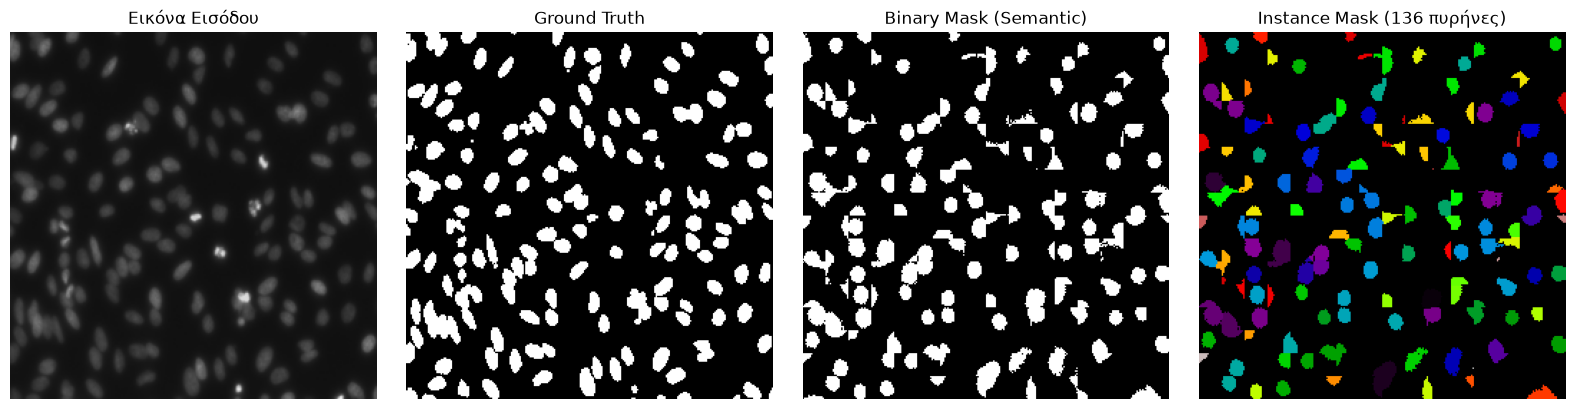

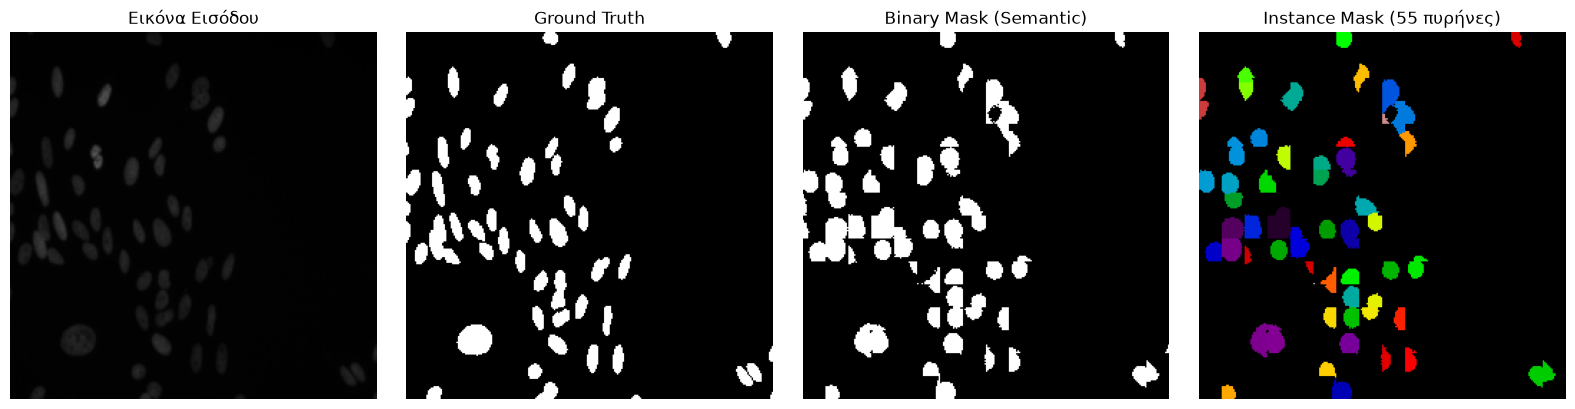

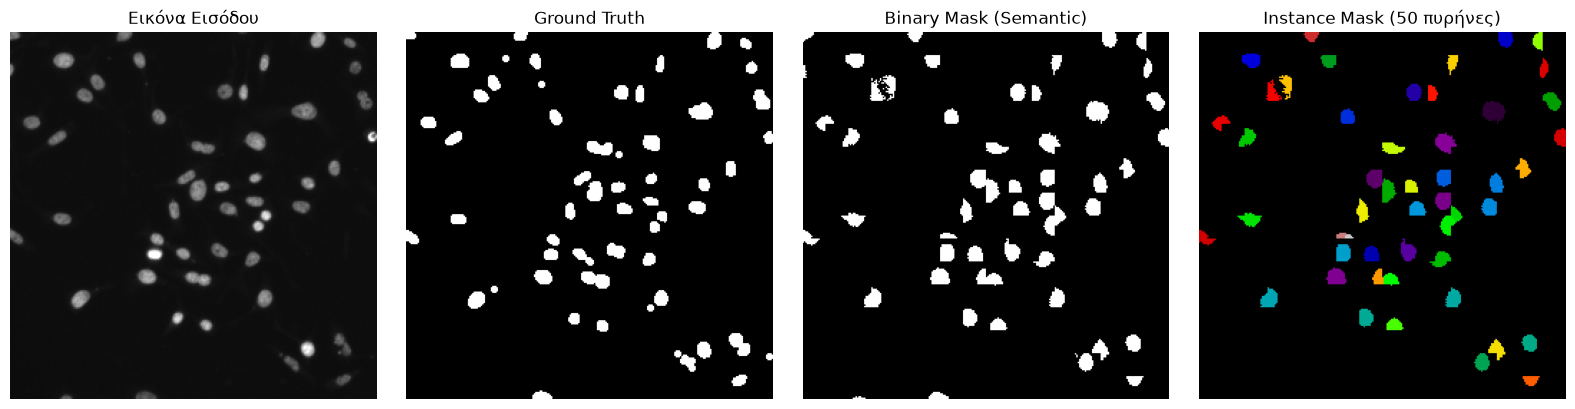

In [31]:
sample_images, sample_masks = next(iter(valid_loader))
sample_images = sample_images.to(device)

model.eval()
with torch.no_grad():
    pred_logits, _ = model(sample_images)
    pred_binary = (torch.sigmoid(pred_logits) > 0.5).float()

for i in range(min(3, pred_binary.shape[0])):
    mask_np = pred_binary[i, 0].cpu().numpy().astype(np.uint8)
    instance_mask, n = binary_mask_to_instances_watershed(mask_np)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(sample_images[i].cpu().permute(1,2,0))
    axes[0].set_title("Εικόνα Εισόδου")
    axes[1].imshow(sample_masks[i, 0].cpu(), cmap='gray')
    axes[1].set_title("Ground Truth")
    axes[2].imshow(mask_np, cmap='gray')
    axes[2].set_title("Binary Mask (Semantic)")
    axes[3].imshow(instance_mask, cmap='nipy_spectral')
    axes[3].set_title(f"Instance Mask ({n} πυρήνες)")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

In [32]:
# Store model parameters so we don't have to re-train every time
torch.save(model.state_dict, "../trained-nets/part-b-transformer")